这个文档是读取郭老师外推生成的数据的

In [9]:
%pip install -e "D:/Learning/PHD1st/magnetic_reconnecion/python"

Obtaining file:///D:/Learning/PHD1st/magnetic_reconnecion/python
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Running setup.py develop for amrvac-pytools
Note: you may need to restart the kernel to use updated packages.


In [1]:
import amrvac_pytools as apt
import matplotlib.pyplot as plt
import numpy as np
ds = apt.load_datfile('C:/Users/19671/Desktop/0618/nlfff.dat')
ds.get_info()
ad = ds.load_all_data()

>> Reading C:/Users/19671/Desktop/0618/nlfff.dat

[INFO] Current file      : nlfff.dat
[INFO] Datfile version   : 5
[INFO] Current time      : 1.5
[INFO] Physics type      : mf
[INFO] Boundaries        : [-6.5954245 -5.1297746  0.1      ] -> [ 6.5954245  5.1297746 10.259549 ]
[INFO] Max AMR level     : 1
[INFO] Uniform mesh      : True
[INFO] Block size        : [18 14 14]
[INFO] Number of blocks  : 8000
----------------------------------------
Known variables: ['m1', 'm2', 'm3', 'b1', 'b2', 'b3']


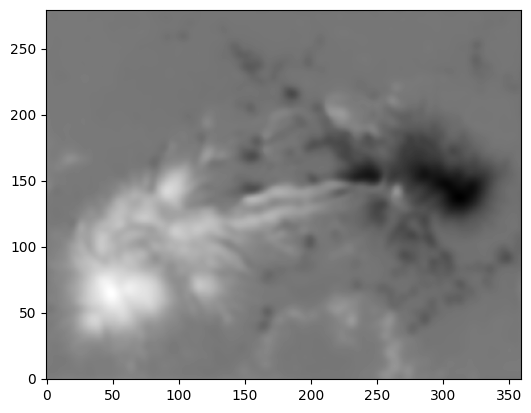

In [3]:
b1 = np.ascontiguousarray(ad['b1'])
b2 = np.ascontiguousarray(ad['b2'])
b3 = np.ascontiguousarray(ad['b3'])
plt.imshow(b3[:,:,1].T,origin='lower',cmap='grey')

In [4]:
with open(r'D:\Learning\PHD1st\magnetic_reconnecion\magnetic_modeling_codes-main\code\null_point\nullpoint\bxyz.blk', 'wb') as file:
    file.write(b1.astype('float32').transpose(2,1,0).tobytes())
    file.write(b2.astype('float32').transpose(2,1,0).tobytes())
    file.write(b3.astype('float32').transpose(2,1,0).tobytes())

In [4]:
from scipy.io import readsav
point=readsav(r'D:\Learning\PHD1st\magnetic_reconnecion\magnetic_modeling_codes-main\code\null_point\nullpoint\null_para.sav')
print(point.keys())
point_position=point['null_position']

dict_keys(['null_position', 'null_position_error', 'null_magnitude', 'null_matrix', 'null_eigen_value', 'null_eigen_vector'])
